Import Libraries

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [38]:
df = pd.read_excel("supermarket_sales_dataset.xlsx")

df.head()

,date,shop,product_id,product_name,category,price,quantity_sold,revenue,stock_level
0,2018-01-01,Shop_1,15,Stop,Household,243.58,7,1705.06,157
1,2018-01-01,Shop_3,3,Kid,Meat,158.25,6,949.50,199
2,2018-01-01,Shop_2,11,Democratic,Meat,61.03,8,488.24,460
3,2018-01-01,Shop_2,4,Fear,Rice & Grains,266.61,8,2132.88,449
4,2018-01-01,Shop_1,26,Within,Meat,229.02,6,1374.12,61


Dataset Overview

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           100000 non-null  datetime64[ns]
 1   shop           100000 non-null  object        
 2   product_id     100000 non-null  int64         
 3   product_name   100000 non-null  object        
 4   category       100000 non-null  object        
 5   price          100000 non-null  float64       
 6   quantity_sold  100000 non-null  int64         
 7   revenue        100000 non-null  float64       
 8   stock_level    100000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 6.9+ MB


In [40]:
df.describe()

,date,product_id,price,quantity_sold,revenue,stock_level
count,100000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,2022-02-04 12:59:21.408000,15.518890,169.75141,9.215830,1570.981296,274.866520
min,2018-01-01 00:00:00,1.000000,42.88000,1.000000,42.880000,50.000000
25%,2020-01-20 00:00:00,8.000000,80.76000,7.000000,712.020000,162.000000
50%,2022-02-01 00:00:00,16.000000,180.56000,9.000000,1415.600000,275.000000
75%,2024-02-24 00:00:00,23.000000,237.34000,11.000000,2166.720000,387.000000
max,2026-03-09 00:00:00,30.000000,283.22000,60.000000,15293.880000,500.000000
std,NaN,8.632151,79.74054,3.936125,1058.764492,130.116588


Data Preprocessing

In [41]:
# Datatype conversion

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

In [42]:
# check missing values

df.isnull().sum()

date             0
shop             0
product_id       0
product_name     0
category         0
price            0
quantity_sold    0
revenue          0
stock_level      0
dtype: int64

EDA 

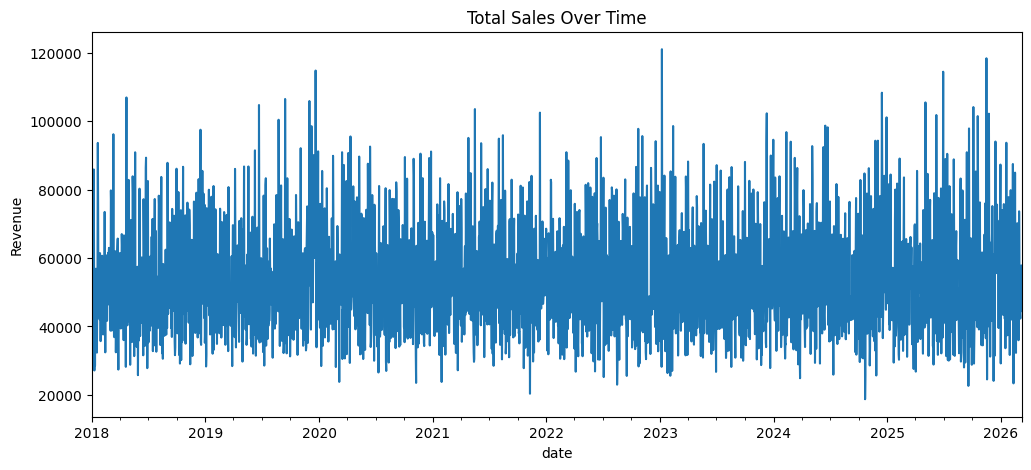

In [43]:
# Total Sales Over Time (this reveals global trend)

daily_sales = df.groupby("date")["revenue"].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Total Sales Over Time")
plt.ylabel("Revenue")
plt.show()

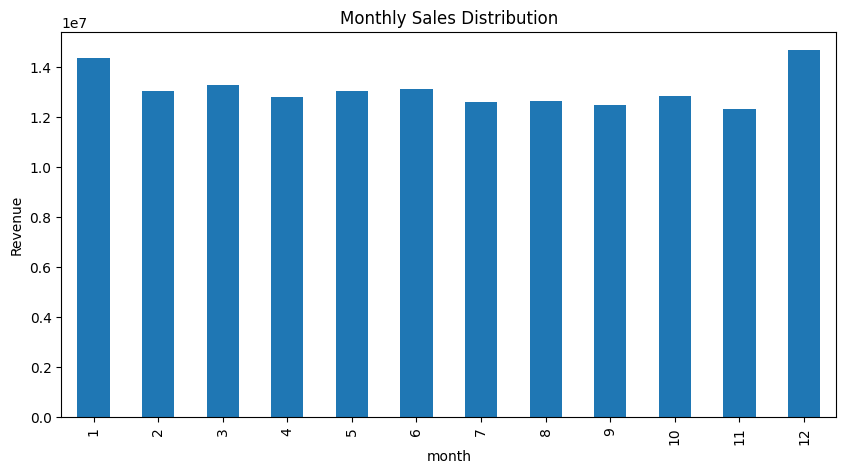

In [44]:
# Monthly Sales Trend
# This helps identify seasonality.

df["month"] = df["date"].dt.month

monthly_sales = df.groupby("month")["revenue"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales Distribution")
plt.ylabel("Revenue")
plt.show()

In [45]:
# Sales by Product
# Find best-selling products.

product_sales = df.groupby("product_name")["quantity_sold"].sum()

top_products = product_sales.sort_values(ascending=False).head(10)

print(top_products)

product_name
Ago             59287
Pm              36070
Now             32771
Goal            32400
Fear            32181
Wife            31446
Success         31441
Business        31334
Particularly    31120
Democratic      30941
Name: quantity_sold, dtype: int64


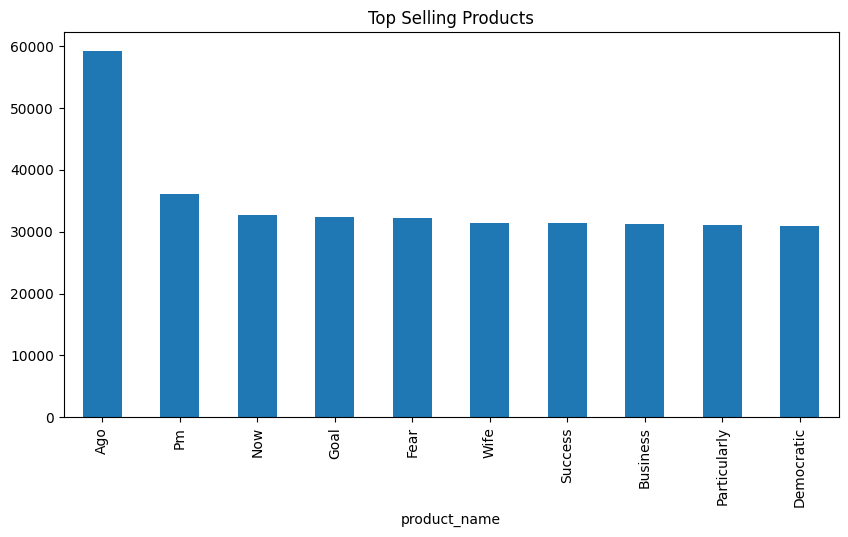

In [46]:
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top Selling Products")
plt.show()

In [47]:
# Low Performing Products

low_products = product_sales.sort_values().head(10)

print(low_products)

product_name
Kid            29283
Exactly        29728
Together       29756
Information    29760
Evidence       29769
Within         29784
Add            29799
Magazine       29971
Lot            30057
Response       30098
Name: quantity_sold, dtype: int64


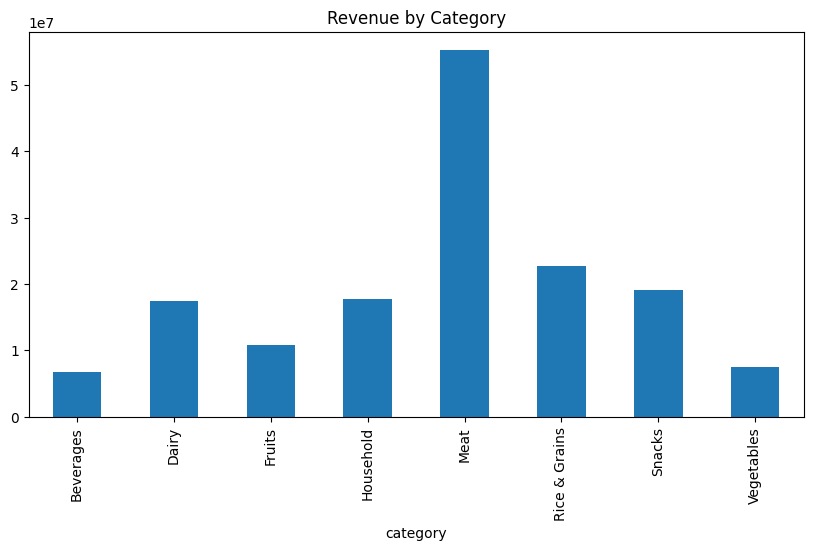

In [48]:
# Category Sales Analysis
# Which categories drive most revenue
# Which categories underperform

category_sales = df.groupby("category")["revenue"].sum()

category_sales.plot(kind="bar", figsize=(10,5))
plt.title("Revenue by Category")
plt.show()

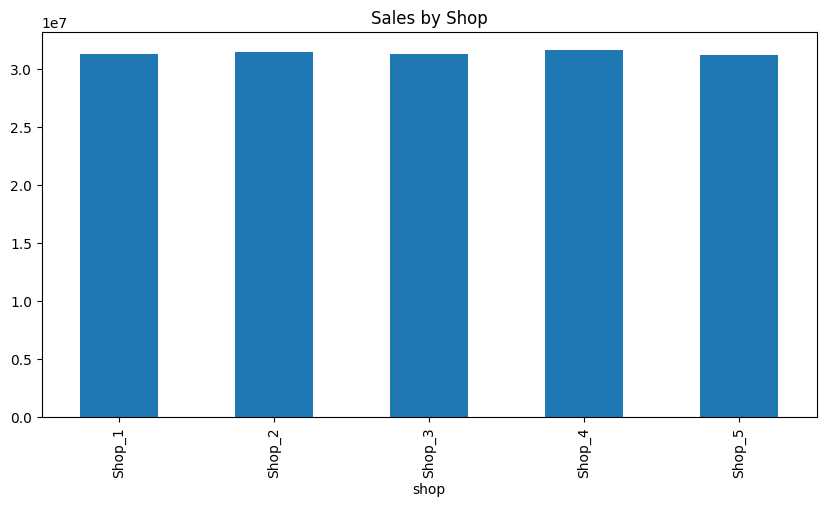

In [49]:
# Shop Performance
# store performance comparison

shop_sales = df.groupby("shop")["revenue"].sum()

shop_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Shop")
plt.show()

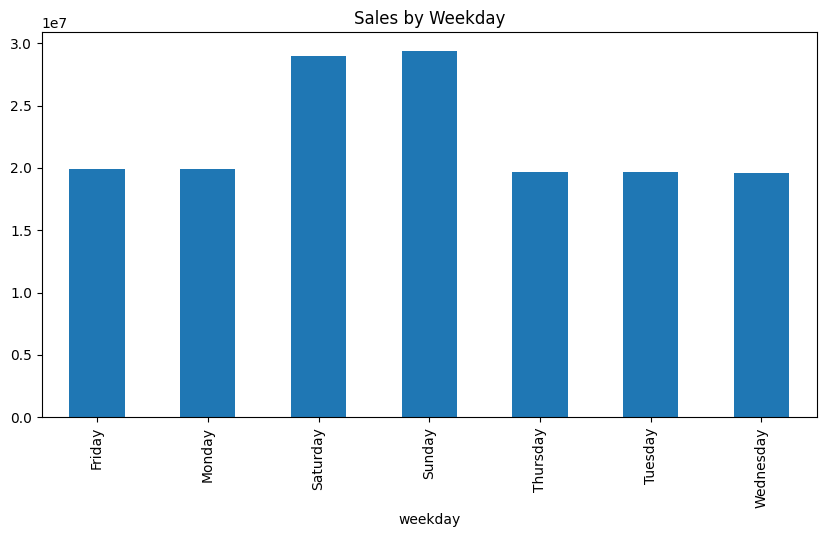

In [50]:
# Weekly Pattern (Retail Insight)
# Retail usually spikes on weekends.

df["weekday"] = df["date"].dt.day_name()

weekday_sales = df.groupby("weekday")["revenue"].sum()

weekday_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Weekday")
plt.show()

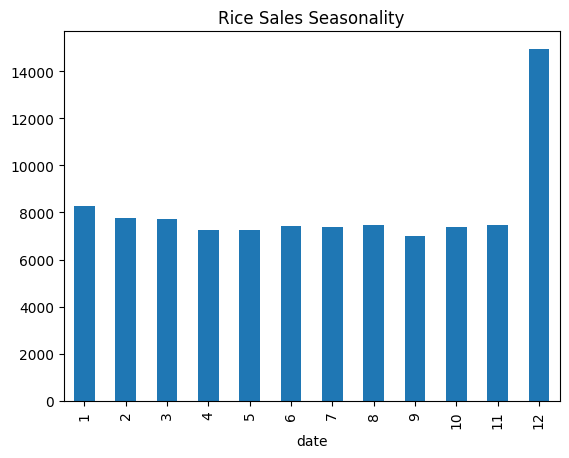

In [51]:
# Product Seasonality Check
# Example for Rice

rice = df[df["category"] == "Rice & Grains"]

rice_month = rice.groupby(rice["date"].dt.month)["quantity_sold"].sum()

rice_month.plot(kind="bar")
plt.title("Rice Sales Seasonality")
plt.show()

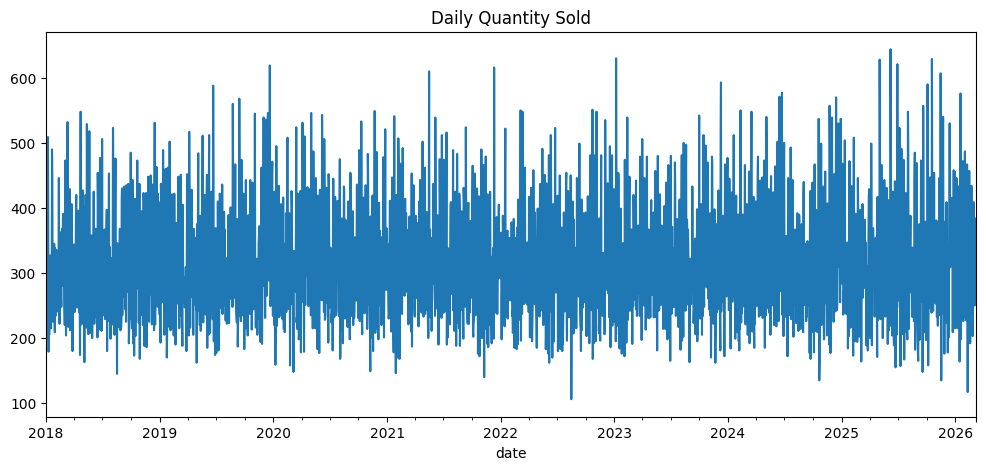

In [52]:
# Daily Sales Time Series
# This is the actual forecasting input.

daily_series = df.groupby("date")["quantity_sold"].sum()

daily_series.plot(figsize=(12,5))
plt.title("Daily Quantity Sold")
plt.show()

Forecasting & Decision Systems

Model 1 — Prophet Forecast (Best for Business Time Series)

In [53]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Step 1 — Prepare Data

In [54]:
df = pd.read_excel("supermarket_sales_dataset.xlsx")

df["date"] = pd.to_datetime(df["date"])

daily_sales = df.groupby("date")["quantity_sold"].sum().reset_index()

daily_sales.columns = ["ds","y"]

Step 2 — Train Prophet Model

In [55]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily_sales)

00:44:09 - cmdstanpy - INFO - Chain [1] start processing
00:44:09 - cmdstanpy - INFO - Chain [1] done processing


Step 3 — Forecast Future Sales

In [56]:
# Predict next 180 days
future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

Step 4 — Visualize Forecast

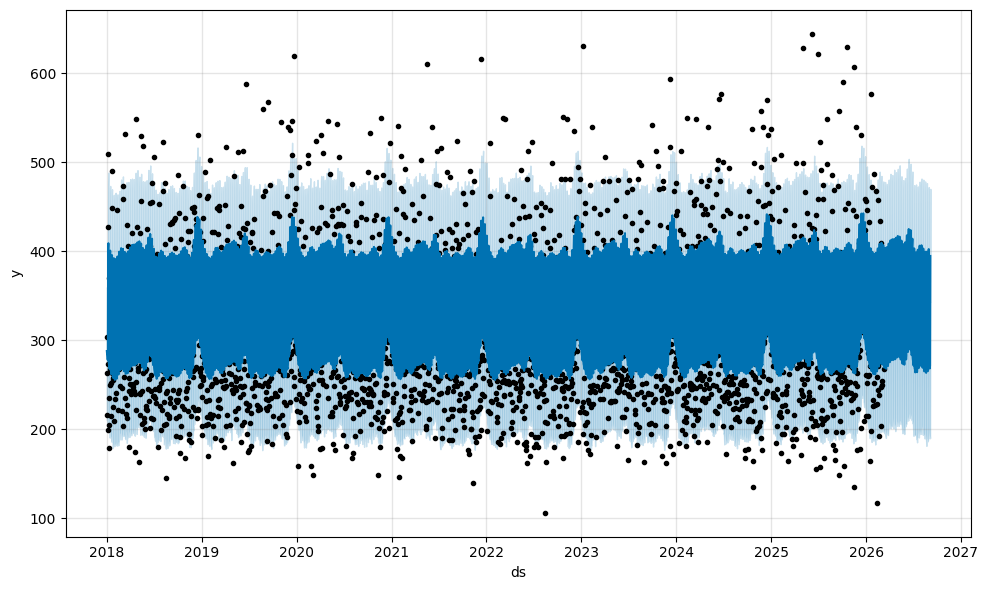

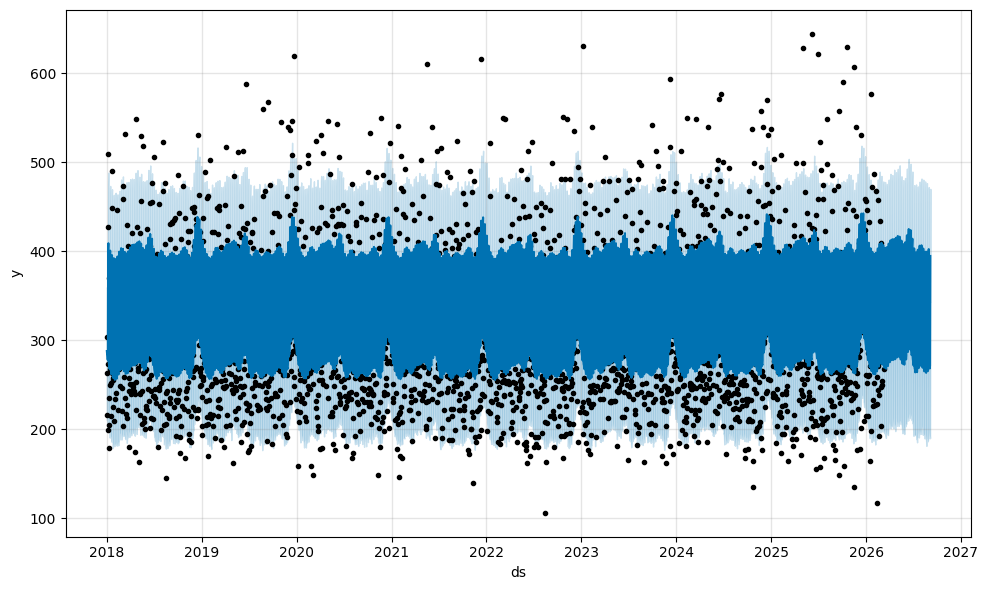

In [57]:
model.plot(forecast)

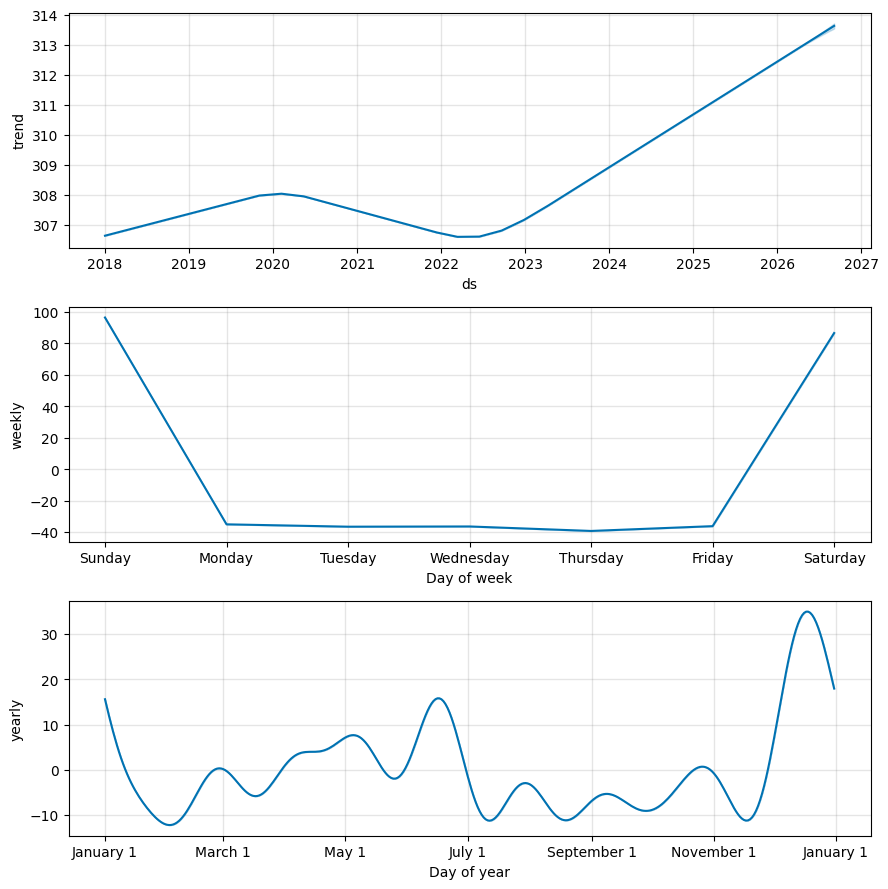

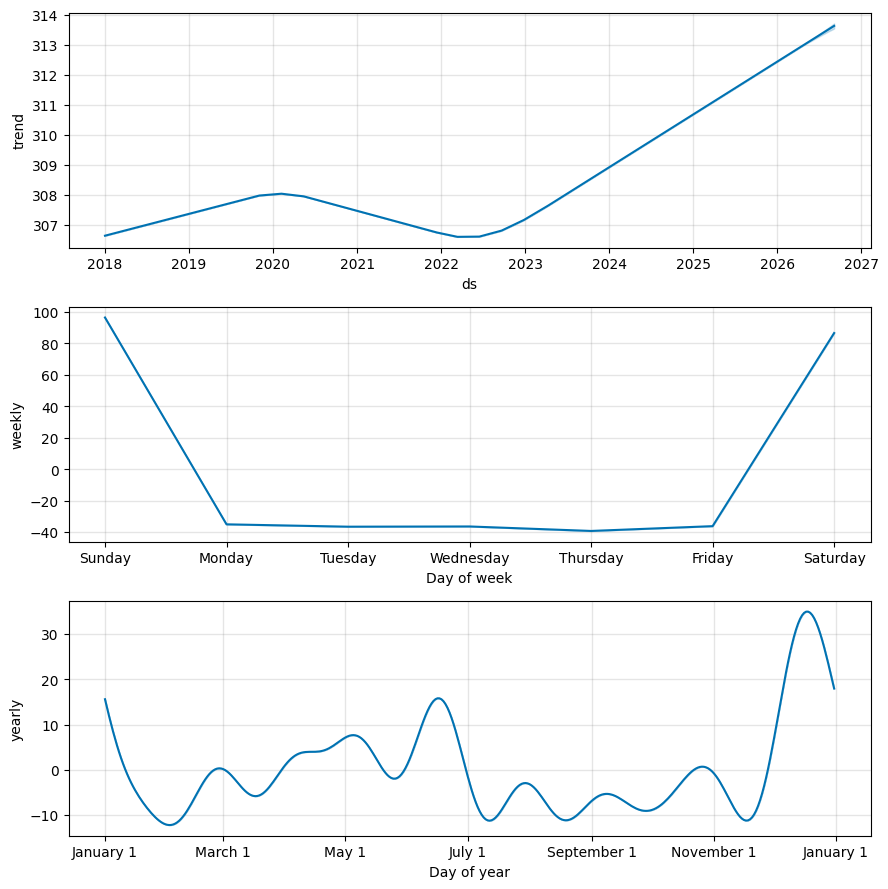

In [58]:
# Seasonality Plots
model.plot_components(forecast)

Model 2 — Product Level Forecast

Instead of predicting total sales, we predict sales per product.

In [63]:
# Example: Forecast Rice Sales

df = pd.read_excel("supermarket_sales_dataset.xlsx")

df["date"] = pd.to_datetime(df["date"])

product_df = df[df["product_name"] == "Rice"]

product_sales = product_df.groupby("date")["quantity_sold"].sum().reset_index()

product_sales.columns = ["ds","y"]

In [64]:
product_sales

,ds,y


Train Prophet

In [65]:
model = Prophet()

model.fit(product_sales)

future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

model.plot(forecast)

ValueError: Dataframe has less than 2 non-NaN rows.

Forecast for ALL Products

In [62]:
products = df["product_name"].unique()

product_forecasts = {}

for product in products:

    temp = df[df["product_name"] == product]

    series = temp.groupby("date")["quantity_sold"].sum().reset_index()

    series.columns = ["ds","y"]

    if len(series) > 30:

        model = Prophet()

        model.fit(series)

        future = model.make_future_dataframe(periods=30)

        forecast = model.predict(future)

        product_forecasts[product] = forecast

00:44:22 - cmdstanpy - INFO - Chain [1] start processing
00:44:22 - cmdstanpy - INFO - Chain [1] done processing
00:44:23 - cmdstanpy - INFO - Chain [1] start processing
00:44:23 - cmdstanpy - INFO - Chain [1] done processing
00:44:24 - cmdstanpy - INFO - Chain [1] start processing
00:44:24 - cmdstanpy - INFO - Chain [1] done processing
00:44:25 - cmdstanpy - INFO - Chain [1] start processing
00:44:25 - cmdstanpy - INFO - Chain [1] done processing
00:44:26 - cmdstanpy - INFO - Chain [1] start processing
00:44:26 - cmdstanpy - INFO - Chain [1] done processing
00:44:28 - cmdstanpy - INFO - Chain [1] start processing
00:44:28 - cmdstanpy - INFO - Chain [1] done processing
00:44:29 - cmdstanpy - INFO - Chain [1] start processing
00:44:30 - cmdstanpy - INFO - Chain [1] done processing
00:44:31 - cmdstanpy - INFO - Chain [1] start processing
00:44:31 - cmdstanpy - INFO - Chain [1] done processing
00:44:33 - cmdstanpy - INFO - Chain [1] start processing
00:44:33 - cmdstanpy - INFO - Chain [1]

Model 3 — Stock Recommendation System

Step 1 — Predict Demand

In [66]:
# Example for next 30 days
future_demand = forecast.tail(30)["yhat"].sum()

Step 2 — Current Stock

In [67]:
current_stock = df[df["product_name"]=="Rice"]["stock_level"].iloc[-1]

IndexError: single positional indexer is out-of-bounds

Step 3 — Stock Recommendation Logic

In [68]:
safety_stock = future_demand * 0.20

recommended_stock = future_demand + safety_stock

Step 4 — Generate Alert

In [69]:
if current_stock < recommended_stock:

    print("ALERT: Reorder stock")

    print("Recommended Stock:", recommended_stock)

NameError: name 'current_stock' is not defined

Detect Low Performing Products

In [70]:
product_trend = df.groupby("product_name")["quantity_sold"].sum()

low_products = product_trend.sort_values().head(10)

print(low_products)

product_name
Kid            29283
Exactly        29728
Together       29756
Information    29760
Evidence       29769
Within         29784
Add            29799
Magazine       29971
Lot            30057
Response       30098
Name: quantity_sold, dtype: int64


Predict Best Future Products

In [71]:
future_sales = {}

for product, forecast in product_forecasts.items():

    future_sales[product] = forecast.tail(30)["yhat"].sum()

best_products = sorted(future_sales.items(), key=lambda x: x[1], reverse=True)

print(best_products[:10])

[('Ago', np.float64(640.318255958495)), ('Pm', np.float64(521.7224482113041)), ('Success', np.float64(493.182190324752)), ('Nor', np.float64(492.0656310345165)), ('Information', np.float64(486.74949729741525)), ('Particularly', np.float64(485.5351220841187)), ('Now', np.float64(481.69792053531603)), ('Wife', np.float64(481.6023199794465)), ('Response', np.float64(468.65434524953196)), ('Kid', np.float64(463.31404002318664))]
